# 숙제 3

데이터과학 입문

서재희 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

`SmokeNow`는 현재 흡연 여부를 나타내지만, 평생 담배를 100개비 이상 피운
적이 없는 사람(`Smoke100 == "No"`)에게는 구조적으로 결측이다. 따라서
현재 흡연 여부를 만들 때는 `Smoke100 == "No"`인 사람을 현재 비흡연자로
재코딩하고, `Smoke100 == "Yes"`인 사람에 대해서만 `SmokeNow` 값을
사용하였다. 분석 대상은 문제의 지시에 따라 20세 이상으로 제한하였다.

## R

``` r
library(tidyverse)
library(NHANES)

adult_smoking_raw <- NHANES::NHANES %>%
  filter(Age >= 20) %>%
  select(
    SmokeNow, Smoke100, Age, Gender, Race1, Education,
    Poverty, BMI, PhysActive
  )

adult_smoking_raw %>%
  count(SmokeNow, Smoke100)
```

    # A tibble: 3 × 3
      SmokeNow Smoke100     n
      <fct>    <fct>    <int>
    1 No       Yes       1745
    2 Yes      Yes       1466
    3 <NA>     No        4024

``` r
adult_smoking <- adult_smoking_raw %>%
  mutate(
    current_smoker = case_when(
      Smoke100 == "No" ~ 0L,
      Smoke100 == "Yes" & SmokeNow == "Yes" ~ 1L,
      Smoke100 == "Yes" & SmokeNow == "No" ~ 0L,
      TRUE ~ NA_integer_
    )
  ) %>%
  select(
    current_smoker, Age, Gender, Race1, Education,
    Poverty, BMI, PhysActive
  ) %>%
  drop_na()

adult_smoking %>%
  summarize(
    n = n(),
    current_smoking_rate = mean(current_smoker)
  )
```

    # A tibble: 1 × 2
          n current_smoking_rate
      <int>                <dbl>
    1  6632                0.200

``` r
smoke_model <- glm(
  current_smoker ~ Age + Gender + Race1 + Education + Poverty + BMI + PhysActive,
  data = adult_smoking,
  family = binomial()
)

coef_table <- as.data.frame(summary(smoke_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    odds_ratio = exp(estimate),
    conf_low = exp(estimate - qnorm(0.975) * std_error),
    conf_high = exp(estimate + qnorm(0.975) * std_error)
  )

coef_table %>%
  filter(term != "(Intercept)") %>%
  arrange(p_value) %>%
  select(term, odds_ratio, conf_low, conf_high, p_value)
```

                          term odds_ratio  conf_low conf_high      p_value
    1                      Age  0.9757029 0.9716777 0.9797449 2.003080e-31
    2                      BMI  0.9591824 0.9493806 0.9690853 1.833542e-15
    3            PhysActiveYes  0.5834498 0.5080952 0.6699800 2.235235e-14
    4                  Poverty  0.8428913 0.8056757 0.8818259 1.185129e-13
    5    EducationCollege Grad  0.3100339 0.2221076 0.4327679 5.904404e-12
    6             Race1Mexican  0.3749024 0.2744381 0.5121439 7.078267e-10
    7               Gendermale  1.4423385 1.2672482 1.6416203 2.907916e-08
    8            Race1Hispanic  0.5582110 0.4009816 0.7770919 5.521071e-04
    9  Education9 - 11th Grade  1.4960217 1.1070721 2.0216217 8.738796e-03
    10   EducationSome College  0.7032823 0.5220384 0.9474514 2.061452e-02
    11              Race1White  1.1406360 0.9328533 1.3946999 1.996644e-01
    12    EducationHigh School  0.9157344 0.6804504 1.2323740 5.612558e-01
    13              Race1Other  0.9653174 0.7128780 1.3071489 8.194772e-01

``` r
smoking_diagnostics <- adult_smoking %>%
  mutate(
    predicted_prob = predict(smoke_model, type = "response"),
    risk_decile = ntile(predicted_prob, 10)
  ) %>%
  group_by(risk_decile) %>%
  summarize(
    n = n(),
    observed_rate = mean(current_smoker),
    predicted_rate = mean(predicted_prob),
    .groups = "drop"
  )

smoking_diagnostics
```

    # A tibble: 10 × 4
       risk_decile     n observed_rate predicted_rate
             <int> <int>         <dbl>          <dbl>
     1           1   664        0.0572         0.0427
     2           2   664        0.0798         0.0667
     3           3   663        0.103          0.0909
     4           4   663        0.0905         0.117 
     5           5   663        0.0965         0.150 
     6           6   663        0.204          0.186 
     7           7   663        0.234          0.229 
     8           8   663        0.294          0.278 
     9           9   663        0.333          0.350 
    10          10   663        0.511          0.493 

``` r
ggplot(smoking_diagnostics, aes(x = predicted_rate, y = observed_rate)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(size = 2.4, color = "#4C78A8") +
  geom_line(color = "#4C78A8") +
  scale_x_continuous(labels = scales::percent) +
  scale_y_continuous(labels = scales::percent) +
  labs(
    title = "Observed and Predicted Current Smoking Rates",
    subtitle = "NHANES adults aged 20 or older, grouped by predicted-risk decile",
    x = "Mean predicted probability",
    y = "Observed current smoking rate"
  ) +
  theme_minimal()
```

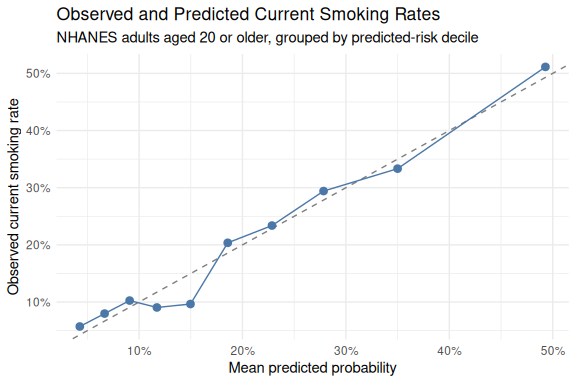

``` r
nhanes_smoking_python_csv <- tempfile(fileext = ".csv")
write_csv(adult_smoking_raw, nhanes_smoking_python_csv, na = "")
```

## Python

``` python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import statsmodels.api as sm
import statsmodels.formula.api as smf

smoking_path = r.nhanes_smoking_python_csv
if not isinstance(smoking_path, str):
    smoking_path = str(smoking_path[0])

adult_smoking_raw_py = pd.read_csv(smoking_path)

print(
    adult_smoking_raw_py
    .groupby(["SmokeNow", "Smoke100"], dropna=False)
    .size()
    .reset_index(name="n")
)
```

      SmokeNow Smoke100     n
    0       No      Yes  1745
    1      Yes      Yes  1466
    2      NaN       No  4024

``` python
conditions = [
    adult_smoking_raw_py["Smoke100"].eq("No"),
    adult_smoking_raw_py["Smoke100"].eq("Yes") & adult_smoking_raw_py["SmokeNow"].eq("Yes"),
    adult_smoking_raw_py["Smoke100"].eq("Yes") & adult_smoking_raw_py["SmokeNow"].eq("No")
]
choices = [0, 1, 0]

adult_smoking_py = adult_smoking_raw_py.copy()
adult_smoking_py["current_smoker"] = np.select(conditions, choices, default=np.nan)

model_vars = [
    "current_smoker", "Age", "Gender", "Race1", "Education",
    "Poverty", "BMI", "PhysActive"
]
adult_smoking_py = adult_smoking_py[model_vars].dropna()

print(pd.DataFrame({
    "n": [len(adult_smoking_py)],
    "current_smoking_rate": [adult_smoking_py["current_smoker"].mean()]
}))
```

          n  current_smoking_rate
    0  6632              0.200241

``` python
smoke_model_py = smf.glm(
    formula=(
        "current_smoker ~ Age + C(Gender) + C(Race1) + "
        "C(Education) + Poverty + BMI + C(PhysActive)"
    ),
    data=adult_smoking_py,
    family=sm.families.Binomial()
).fit()

coef_table_py = pd.DataFrame({
    "term": smoke_model_py.params.index,
    "estimate": smoke_model_py.params.values,
    "std_error": smoke_model_py.bse.values,
    "statistic": smoke_model_py.tvalues.values,
    "p_value": smoke_model_py.pvalues.values
})
coef_table_py["odds_ratio"] = np.exp(coef_table_py["estimate"])
coef_table_py["conf_low"] = np.exp(
    coef_table_py["estimate"] - 1.96 * coef_table_py["std_error"]
)
coef_table_py["conf_high"] = np.exp(
    coef_table_py["estimate"] + 1.96 * coef_table_py["std_error"]
)

print(
    coef_table_py
    .loc[coef_table_py["term"] != "Intercept",
         ["term", "odds_ratio", "conf_low", "conf_high", "p_value"]]
    .sort_values("p_value")
)
```

                                  term  odds_ratio  ...  conf_high       p_value
    11                             Age    0.975703  ...   0.979745  2.003080e-31
    13                             BMI    0.959182  ...   0.969086  1.833542e-15
    10            C(PhysActive)[T.Yes]    0.583450  ...   0.669982  2.235235e-14
    12                         Poverty    0.842891  ...   0.881827  1.185129e-13
    7     C(Education)[T.College Grad]    0.310034  ...   0.432771  5.904404e-12
    3              C(Race1)[T.Mexican]    0.374902  ...   0.512147  7.078267e-10
    1                C(Gender)[T.male]    1.442338  ...   1.641624  2.907916e-08
    2             C(Race1)[T.Hispanic]    0.558211  ...   0.777097  5.521071e-04
    6   C(Education)[T.9 - 11th Grade]    1.496022  ...   2.021633  8.738796e-03
    9     C(Education)[T.Some College]    0.703282  ...   0.947457  2.061452e-02
    5                C(Race1)[T.White]    1.140636  ...   1.394705  1.996644e-01
    8      C(Education)[T.High School]    0.915734  ...   1.232381  5.612558e-01
    4                C(Race1)[T.Other]    0.965317  ...   1.307156  8.194772e-01

    [13 rows x 5 columns]

``` python
adult_smoking_py["predicted_prob"] = smoke_model_py.predict(adult_smoking_py)
adult_smoking_py["risk_decile"] = pd.qcut(
    adult_smoking_py["predicted_prob"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

smoking_diagnostics_py = (
    adult_smoking_py
    .groupby("risk_decile", as_index=False)
    .agg(
        n=("current_smoker", "size"),
        observed_rate=("current_smoker", "mean"),
        predicted_rate=("predicted_prob", "mean")
    )
)

print(smoking_diagnostics_py)
```

       risk_decile    n  observed_rate  predicted_rate
    0            1  664       0.057229        0.042707
    1            2  663       0.079940        0.066651
    2            3  664       0.102410        0.090857
    3            4  662       0.090634        0.117249
    4            5  663       0.096531        0.149665
    5            6  663       0.203620        0.185690
    6            7  664       0.233434        0.228494
    7            8  662       0.294562        0.278369
    8            9  664       0.332831        0.349932
    9           10  663       0.511312        0.492924

``` python
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.plot(
    smoking_diagnostics_py["predicted_rate"],
    smoking_diagnostics_py["observed_rate"],
    marker="o",
    color="#4C78A8"
)
ax.set_title("Observed and Predicted Current Smoking Rates")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed current smoking rate")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

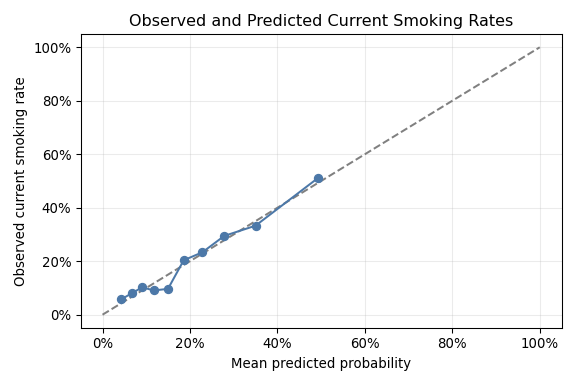

로지스틱 회귀 결과표에서 오즈비가 1보다 크면 현재 흡연 오즈가 커지는
방향, 1보다 작으면 현재 흡연 오즈가 작아지는 방향으로 해석한다.
신뢰구간이 1을 포함하지 않고 p-value가 작은 변수들을 현재 흡연 여부를
설명하는 주요 예측변수로 볼 수 있다. 이 모형은 `SmokeNow`의 구조적
결측을 그대로 버리지 않고, `Smoke100 == "No"`인 사람들을 현재 비흡연자로
포함했다는 점이 핵심이다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

먼저 `Teams` 자료에서 한 행이 한 팀의 한 시즌을 나타내도록 사용하였다.
`R`은 득점(`RS`)으로 이름을 바꾸고, 승률은 `WPct = W / (W + L)`로
계산하였다. 분석 기간은 2010년 이후부터 자료에 존재하는 최신 연도까지로
제한하되, 단축 시즌인 2020년은 제외하였다.

Bill James 공식은
$$  WPct = \frac{1}{1 + (RA / RS)^k}$$
이므로 `log_run_ratio = log(RS / RA)`를 사용하면
$$  \mathrm{logit}(WPct) = k \log(RS / RA)$$
가 된다. 따라서 절편이 없는 로지스틱 회귀의 기울기는 Bill James 공식의
지수 `k`와 직접 비교할 수 있다.

## R

``` r
library(tidyverse)
library(Lahman)

available_end_year <- min(2025, max(Lahman::Teams$yearID, na.rm = TRUE))

teams_21 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= available_end_year,
    yearID != 2020
  ) %>%
  transmute(
    yearID,
    teamID,
    lgID,
    W,
    L,
    games = W + L,
    RS = R,
    RA
  ) %>%
  filter(games > 0, RS > 0, RA > 0) %>%
  mutate(
    WPct = W / games,
    run_ratio = RS / RA,
    log_run_ratio = log(run_ratio),
    logRS = log(RS),
    logRA = log(RA)
  )

teams_21 %>%
  summarize(
    first_year = min(yearID),
    last_year = max(yearID),
    n = n(),
    mean_WPct = mean(WPct)
  )
```

      first_year last_year   n mean_WPct
    1       2010      2025 450 0.4999927

``` r
# 1. Bill James 비선형 모형으로 k 추정
bill_james_nls <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data = teams_21,
  start = list(k = 2)
)

nls_summary <- summary(bill_james_nls)
k_hat <- coef(bill_james_nls)[["k"]]
k_se <- nls_summary$parameters["k", "Std. Error"]

bill_james_k <- tibble(
  method = "Nonlinear Bill James model",
  term = "k",
  estimate = k_hat,
  std_error = k_se,
  conf_low = k_hat - qnorm(0.975) * k_se,
  conf_high = k_hat + qnorm(0.975) * k_se
)

bill_james_k
```

    # A tibble: 1 × 6
      method                     term  estimate std_error conf_low conf_high
      <chr>                      <chr>    <dbl>     <dbl>    <dbl>     <dbl>
    1 Nonlinear Bill James model k         1.75    0.0293     1.70      1.81

``` r
teams_21 <- teams_21 %>%
  mutate(
    nls_pred_WPct = predict(bill_james_nls)
  )

# 2. 절편 없는 로지스틱 회귀: logit(WPct) = beta1 * log(RS / RA)
# cbind(W, L)은 WPct를 W + L번의 시행에서 얻은 승리 비율로 보는 binomial GLM 표현이다.
logit_ratio_model <- glm(
  cbind(W, L) ~ 0 + log_run_ratio,
  data = teams_21,
  family = binomial()
)

logit_ratio_coef <- as.data.frame(summary(logit_ratio_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

logit_ratio_coef
```

               term estimate  std_error statistic       p_value conf_low conf_high
    1 log_run_ratio 1.753203 0.04561729  38.43287 3.952525e-323 1.663795  1.842612

``` r
bind_rows(
  bill_james_k %>% select(method, term, estimate, conf_low, conf_high),
  logit_ratio_coef %>%
    transmute(
      method = "No-intercept binomial GLM",
      term,
      estimate,
      conf_low,
      conf_high
    )
)
```

    # A tibble: 2 × 5
      method                     term          estimate conf_low conf_high
      <chr>                      <chr>            <dbl>    <dbl>     <dbl>
    1 Nonlinear Bill James model k                 1.75     1.70      1.81
    2 No-intercept binomial GLM  log_run_ratio     1.75     1.66      1.84

``` r
teams_21 <- teams_21 %>%
  mutate(
    logit_pred_WPct = fitted(logit_ratio_model),
    eta = predict(logit_ratio_model, type = "link"),
    deviance_resid = residuals(logit_ratio_model, type = "deviance")
  )

# 3-i. Residual deviance를 카이제곱 분포와 비교
deviance_check <- tibble(
  residual_deviance = deviance(logit_ratio_model),
  df_residual = df.residual(logit_ratio_model),
  p_value = pchisq(
    residual_deviance,
    df = df_residual,
    lower.tail = FALSE
  )
)

deviance_check
```

    # A tibble: 1 × 3
      residual_deviance df_residual p_value
                  <dbl>       <int>   <dbl>
    1              180.         449       1

``` r
# 3-ii. Deviance residuals vs linear predictors
ggplot(teams_21, aes(x = eta, y = deviance_resid)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(alpha = 0.65) +
  labs(
    title = "Deviance Residuals vs Linear Predictors",
    x = "Linear predictor eta",
    y = "Deviance residual"
  ) +
  theme_minimal()
```

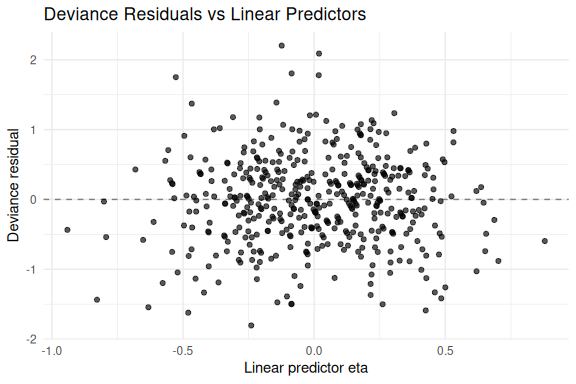

``` r
# 3-iii. 관측 승률과 예측 승률 비교
ggplot(teams_21, aes(x = WPct, y = logit_pred_WPct)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(alpha = 0.65) +
  labs(
    title = "Observed vs Predicted Winning Percentage",
    x = "Observed WPct",
    y = "Predicted WPct"
  ) +
  theme_minimal()
```

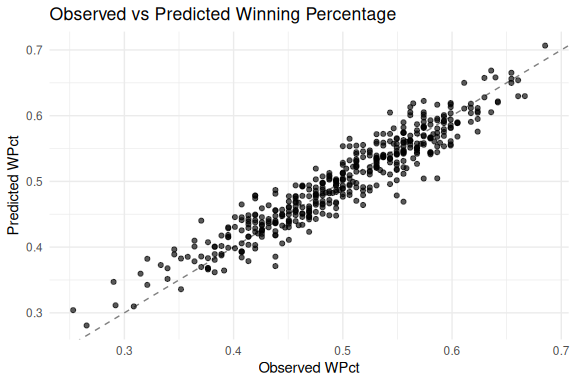

``` r
# 4. log(RS), log(RA)를 따로 넣은 절편 없는 로지스틱선형회귀
log_runs_model <- glm(
  cbind(W, L) ~ 0 + logRS + logRA,
  data = teams_21,
  family = binomial()
)

log_runs_coef <- as.data.frame(summary(log_runs_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

log_runs_coef
```

       term  estimate  std_error statistic       p_value  conf_low conf_high
    1 logRS  1.753153 0.04561853  38.43072 3.952525e-323  1.663742  1.842563
    2 logRA -1.753561 0.04562946 -38.43047 3.952525e-323 -1.842993 -1.664129

``` r
model_comparison <- tibble(
  quantity = c(
    "Nonlinear k",
    "Single-slope GLM beta1",
    "Two-predictor GLM beta_logRS",
    "Two-predictor GLM -beta_logRA"
  ),
  estimate = c(
    k_hat,
    coef(logit_ratio_model)[["log_run_ratio"]],
    coef(log_runs_model)[["logRS"]],
    -coef(log_runs_model)[["logRA"]]
  )
)

model_comparison
```

    # A tibble: 4 × 2
      quantity                      estimate
      <chr>                            <dbl>
    1 Nonlinear k                       1.75
    2 Single-slope GLM beta1            1.75
    3 Two-predictor GLM beta_logRS      1.75
    4 Two-predictor GLM -beta_logRA     1.75

## Python

``` python
import numpy as np
import pandas as pd
import pylahman
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy import stats

def get_pylahman_table(name):
    for candidate in (name, name.lower(), name.capitalize(), name.upper()):
        if hasattr(pylahman, candidate):
            return getattr(pylahman, candidate)()
    raise AttributeError(f"pylahman has no table named {name}")

Teams_py = get_pylahman_table("Teams")
available_end_year_py = min(2025, int(Teams_py["yearID"].max()))

teams_21_py = (
    Teams_py
    .loc[
        (Teams_py["yearID"] >= 2010)
        & (Teams_py["yearID"] <= available_end_year_py)
        & (Teams_py["yearID"] != 2020),
        ["yearID", "teamID", "lgID", "W", "L", "R", "RA"]
    ]
    .rename(columns={"R": "RS"})
    .copy()
)

for col in ["yearID", "W", "L", "RS", "RA"]:
    teams_21_py[col] = pd.to_numeric(teams_21_py[col], errors="coerce")

teams_21_py["games"] = teams_21_py["W"] + teams_21_py["L"]
teams_21_py = teams_21_py.loc[
    (teams_21_py["games"] > 0)
    & (teams_21_py["RS"] > 0)
    & (teams_21_py["RA"] > 0)
].copy()

teams_21_py["WPct"] = teams_21_py["W"] / teams_21_py["games"]
teams_21_py["run_ratio"] = teams_21_py["RS"] / teams_21_py["RA"]
teams_21_py["log_run_ratio"] = np.log(teams_21_py["run_ratio"])
teams_21_py["logRS"] = np.log(teams_21_py["RS"])
teams_21_py["logRA"] = np.log(teams_21_py["RA"])

print(pd.DataFrame({
    "first_year": [teams_21_py["yearID"].min()],
    "last_year": [teams_21_py["yearID"].max()],
    "n": [len(teams_21_py)],
    "mean_WPct": [teams_21_py["WPct"].mean()]
}))
```

       first_year  last_year    n  mean_WPct
    0        2010       2024  420   0.499992

``` python
# 1. Bill James 비선형 모형으로 k 추정
def bill_james_curve(run_ratio, k):
    return 1 / (1 + (1 / run_ratio) ** k)

popt, pcov = curve_fit(
    bill_james_curve,
    teams_21_py["run_ratio"].astype(float).to_numpy(),
    teams_21_py["WPct"].astype(float).to_numpy(),
    p0=[2.0],
    maxfev=10000
)

k_hat_py = popt[0]
k_se_py = np.sqrt(np.diag(pcov))[0]

bill_james_k_py = pd.DataFrame({
    "method": ["Nonlinear Bill James model"],
    "term": ["k"],
    "estimate": [k_hat_py],
    "std_error": [k_se_py],
    "conf_low": [k_hat_py - 1.96 * k_se_py],
    "conf_high": [k_hat_py + 1.96 * k_se_py]
})

print(bill_james_k_py)
```

                           method term  estimate  std_error  conf_low  conf_high
    0  Nonlinear Bill James model    k  1.761041   0.030061  1.702121   1.819961

``` python
teams_21_py["nls_pred_WPct"] = bill_james_curve(
    teams_21_py["run_ratio"],
    k_hat_py
)

# 2. 절편 없는 로지스틱 회귀: logit(WPct) = beta1 * log(RS / RA)
endog = teams_21_py[["W", "L"]].astype(float).to_numpy()
exog_ratio = teams_21_py[["log_run_ratio"]].astype(float)

logit_ratio_model_py = sm.GLM(
    endog,
    exog_ratio,
    family=sm.families.Binomial()
).fit()

logit_ratio_coef_py = pd.DataFrame({
    "term": logit_ratio_model_py.params.index,
    "estimate": logit_ratio_model_py.params.values,
    "std_error": logit_ratio_model_py.bse.values,
    "statistic": logit_ratio_model_py.tvalues.values,
    "p_value": logit_ratio_model_py.pvalues.values
})
logit_ratio_coef_py["conf_low"] = (
    logit_ratio_coef_py["estimate"] - 1.96 * logit_ratio_coef_py["std_error"]
)
logit_ratio_coef_py["conf_high"] = (
    logit_ratio_coef_py["estimate"] + 1.96 * logit_ratio_coef_py["std_error"]
)

print(logit_ratio_coef_py)
```

                term  estimate  std_error  ...        p_value  conf_low  conf_high
    0  log_run_ratio  1.760815   0.047136  ...  2.011270e-305  1.668429   1.853201

    [1 rows x 7 columns]

``` python
print(pd.concat([
    bill_james_k_py[["method", "term", "estimate", "conf_low", "conf_high"]],
    logit_ratio_coef_py.assign(method="No-intercept binomial GLM")[
        ["method", "term", "estimate", "conf_low", "conf_high"]
    ]
], ignore_index=True))
```

                           method           term  estimate  conf_low  conf_high
    0  Nonlinear Bill James model              k  1.761041  1.702121   1.819961
    1   No-intercept binomial GLM  log_run_ratio  1.760815  1.668429   1.853201

``` python
teams_21_py["logit_pred_WPct"] = logit_ratio_model_py.predict(exog_ratio)
teams_21_py["eta"] = exog_ratio.to_numpy() @ logit_ratio_model_py.params.to_numpy()
teams_21_py["deviance_resid"] = logit_ratio_model_py.resid_deviance

# 3-i. Residual deviance를 카이제곱 분포와 비교
deviance_check_py = pd.DataFrame({
    "residual_deviance": [logit_ratio_model_py.deviance],
    "df_residual": [logit_ratio_model_py.df_resid],
    "p_value": [stats.chi2.sf(logit_ratio_model_py.deviance, logit_ratio_model_py.df_resid)]
})

print(deviance_check_py)
```

       residual_deviance  df_residual  p_value
    0         165.673424          419      1.0

``` python
# 3-ii. Deviance residuals vs linear predictors
fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, linestyle="--", color="gray")
ax.scatter(teams_21_py["eta"], teams_21_py["deviance_resid"], alpha=0.65)
ax.set_title("Deviance Residuals vs Linear Predictors")
ax.set_xlabel("Linear predictor eta")
ax.set_ylabel("Deviance residual")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

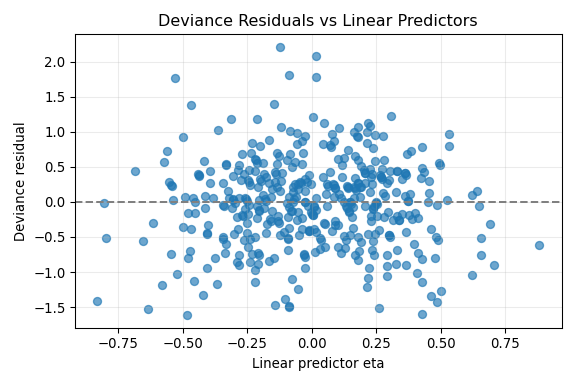

``` python
# 3-iii. 관측 승률과 예측 승률 비교
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0.25, 0.75], [0.25, 0.75], linestyle="--", color="gray")
ax.scatter(teams_21_py["WPct"], teams_21_py["logit_pred_WPct"], alpha=0.65)
ax.set_title("Observed vs Predicted Winning Percentage")
ax.set_xlabel("Observed WPct")
ax.set_ylabel("Predicted WPct")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

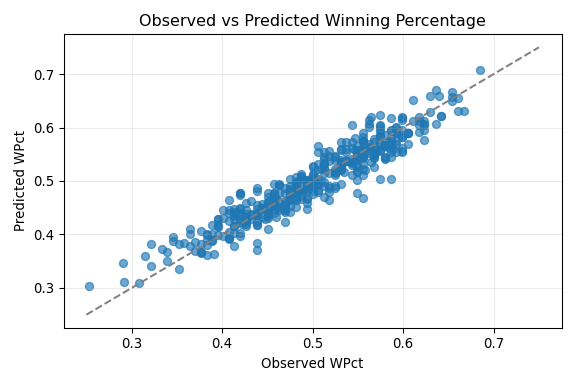

``` python
# 4. log(RS), log(RA)를 따로 넣은 절편 없는 로지스틱선형회귀
exog_runs = teams_21_py[["logRS", "logRA"]].astype(float)

log_runs_model_py = sm.GLM(
    endog,
    exog_runs,
    family=sm.families.Binomial()
).fit()

log_runs_coef_py = pd.DataFrame({
    "term": log_runs_model_py.params.index,
    "estimate": log_runs_model_py.params.values,
    "std_error": log_runs_model_py.bse.values,
    "statistic": log_runs_model_py.tvalues.values,
    "p_value": log_runs_model_py.pvalues.values
})
log_runs_coef_py["conf_low"] = (
    log_runs_coef_py["estimate"] - 1.96 * log_runs_coef_py["std_error"]
)
log_runs_coef_py["conf_high"] = (
    log_runs_coef_py["estimate"] + 1.96 * log_runs_coef_py["std_error"]
)

print(log_runs_coef_py)
```

        term  estimate  std_error  statistic        p_value  conf_low  conf_high
    0  logRS  1.760742   0.047137  37.353827  2.197450e-305  1.668354   1.853130
    1  logRA -1.761107   0.047146 -37.354375  2.152970e-305 -1.853513  -1.668701

``` python
model_comparison_py = pd.DataFrame({
    "quantity": [
        "Nonlinear k",
        "Single-slope GLM beta1",
        "Two-predictor GLM beta_logRS",
        "Two-predictor GLM -beta_logRA"
    ],
    "estimate": [
        k_hat_py,
        logit_ratio_model_py.params["log_run_ratio"],
        log_runs_model_py.params["logRS"],
        -log_runs_model_py.params["logRA"]
    ]
})

print(model_comparison_py)
```

                            quantity  estimate
    0                    Nonlinear k  1.761041
    1         Single-slope GLM beta1  1.760815
    2   Two-predictor GLM beta_logRS  1.760742
    3  Two-predictor GLM -beta_logRA  1.761107

비선형 Bill James 모형의 `k`와 절편 없는 로지스틱 회귀의 `log_run_ratio`
계수는 같은 방향의 양수이며, 모두 득점이 실점보다 많을수록 승률이
증가한다는 관계를 나타낸다. 두 추정치가 완전히 같을 필요는 없는데,
비선형 최소제곱은 승률의 제곱오차를 최소화하고, 로지스틱 회귀는 승패
횟수에 대한 이항 가능도를 기준으로 적합하기 때문이다.

Residual deviance가 자유도에 비해 지나치게 크고 카이제곱 비교 p-value가
매우 작다면, 단순한 한 변수 Bill James 모형만으로 팀 승률의 모든 변동을
설명하기에는 부족하다고 볼 수 있다. 그러나 deviance residual 산점도와
관측-예측 승률 산점도에서 강한 체계적 패턴이 작고 점들이 대체로 대각선
근처에 모이면, 득실점 비율만으로도 승률의 큰 흐름은 잘 설명한다고 해석할
수 있다.

마지막 모형에서 `logRS`의 계수는 양수, `logRA`의 계수는 음수로 나타나는
것이 자연스럽다. Bill James 모형이 정확히 성립한다면 두 계수는 각각
`k`와 `-k`에 가까워야 한다. 따라서 `logRS`와 `-logRA`의 추정치가 앞의
`k` 추정치와 비슷하면, 득점과 실점을 따로 넣은 로지스틱선형회귀도 Bill
James 모형과 유사한 구조를 회복한다고 볼 수 있다.

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

이 문제에서도 한 행은 한 팀의 한 시즌을 나타낸다. 반응변수는 승률
`WPct`이지만, 로지스틱 회귀에서는 각 팀 시즌을 `W`번 성공과 `L`번 실패를
가진 이항 관측값으로 보아 `cbind(W, L)` 형태로 적합하였다. 이렇게 하면
시즌별 경기 수를 자연스럽게 반영할 수 있다.

## R

``` r
library(tidyverse)
library(Lahman)

available_end_year <- min(2025, max(Lahman::Teams$yearID, na.rm = TRUE))

candidate_predictors <- c(
  "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
  "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
  "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
)

teams_22 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= available_end_year,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    games = W + L,
    WPct = W / games,
    logRS = log(RS),
    logRA = log(RA),
    log_run_ratio = log(RS / RA)
  )

missing_predictors <- setdiff(candidate_predictors, names(teams_22))
missing_predictors
```

    character(0)

``` r
model_predictors <- intersect(candidate_predictors, names(teams_22))

teams_22_model <- teams_22 %>%
  select(
    yearID, teamID, W, L, games, WPct, log_run_ratio,
    all_of(model_predictors)
  ) %>%
  filter(games > 0, W > 0, L > 0) %>%
  drop_na()

teams_22_model %>%
  summarize(
    first_year = min(yearID),
    last_year = max(yearID),
    n = n(),
    mean_WPct = mean(WPct)
  )
```

      first_year last_year   n mean_WPct
    1       2010      2025 450 0.4999927

``` r
full_formula <- reformulate(
  model_predictors,
  response = "cbind(W, L)"
)

full_model <- glm(
  full_formula,
  data = teams_22_model,
  family = binomial()
)

step_model <- step(
  full_model,
  direction = "both",
  trace = 0
)

selected_terms <- attr(terms(step_model), "term.labels")
selected_terms
```

    [1] "logRS" "logRA" "CG"    "SHO"   "SV"   

``` r
step_coef <- as.data.frame(summary(step_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

step_coef
```

             term     estimate   std_error  statistic       p_value      conf_low
    1 (Intercept) -2.694018831 0.842063816  -3.199305  1.377594e-03 -4.3444335826
    2       logRS  1.615284336 0.071879998  22.471959 7.807148e-112  1.4744021288
    3       logRA -1.284160145 0.101523976 -12.648836  1.135443e-36 -1.4831434821
    4          CG  0.004572773 0.003014313   1.517020  1.292617e-01 -0.0013351719
    5         SHO  0.004669481 0.002530739   1.845106  6.502210e-02 -0.0002906752
    6          SV  0.011103924 0.001324340   8.384497  5.094328e-17  0.0085082652
         conf_high
    1 -1.043604079
    2  1.756166543
    3 -1.085176808
    4  0.010480717
    5  0.009629638
    6  0.013699582

``` r
drop_table <- as.data.frame(drop1(step_model, test = "Chisq")) %>%
  rownames_to_column("term") %>%
  filter(term != "<none>")

drop_table
```

       term Df Deviance      AIC        LRT      Pr(>Chi)
    1 logRS  1 616.2883 3109.533 510.168964 5.827105e-113
    2 logRA  1 266.7832 2760.028 160.663890  8.102110e-37
    3    CG  1 108.4216 2601.666   2.302232  1.291882e-01
    4   SHO  1 109.5239 2602.768   3.404572  6.501599e-02
    5    SV  1 176.5023 2669.747  70.382998  4.883904e-17

``` r
weak_terms <- drop_table %>%
  filter(!is.na(`Pr(>Chi)`), `Pr(>Chi)` > 0.10) %>%
  pull(term)

weak_terms
```

    [1] "CG"

``` r
if (length(weak_terms) > 0) {
  refined_terms <- setdiff(selected_terms, weak_terms)
  refined_formula <- reformulate(
    refined_terms,
    response = "cbind(W, L)"
  )
  refined_model <- glm(
    refined_formula,
    data = teams_22_model,
    family = binomial()
  )
} else {
  refined_model <- step_model
}

# p-value가 큰 변수를 제거하더라도 AIC가 2 이상 악화되면 AIC 선택 모형을 유지한다.
final_model <- if (AIC(refined_model) <= AIC(step_model) + 2) {
  refined_model
} else {
  step_model
}

final_terms <- attr(terms(final_model), "term.labels")
final_terms
```

    [1] "logRS" "logRA" "SHO"   "SV"   

``` r
final_coef <- as.data.frame(summary(final_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

final_coef
```

             term     estimate   std_error  statistic       p_value      conf_low
    1 (Intercept) -2.359663184 0.812720654  -2.903412  3.691203e-03 -3.952566e+00
    2       logRS  1.606236824 0.071628992  22.424395 2.275676e-111  1.465847e+00
    3       logRA -1.322064166 0.098413479 -13.433771  3.833791e-41 -1.514951e+00
    4         SHO  0.004955674 0.002523497   1.963812  4.955190e-02  9.710501e-06
    5          SV  0.010697442 0.001296796   8.249133  1.595481e-16  8.155768e-03
         conf_high
    1 -0.766759972
    2  1.746627069
    3 -1.129177292
    4  0.009901638
    5  0.013239115

``` r
bill_james_glm <- glm(
  cbind(W, L) ~ 0 + log_run_ratio,
  data = teams_22_model,
  family = binomial()
)

model_rmse <- function(model) {
  sqrt(mean((teams_22_model$WPct - fitted(model))^2))
}

model_comparison_22 <- tibble(
  model = c(
    "Bill James one-slope model",
    "Full multivariable model",
    "AIC stepwise model",
    "Final selected model"
  ),
  df_model = c(
    length(coef(bill_james_glm)),
    length(coef(full_model)),
    length(coef(step_model)),
    length(coef(final_model))
  ),
  AIC = c(
    AIC(bill_james_glm),
    AIC(full_model),
    AIC(step_model),
    AIC(final_model)
  ),
  residual_deviance = c(
    deviance(bill_james_glm),
    deviance(full_model),
    deviance(step_model),
    deviance(final_model)
  ),
  df_residual = c(
    df.residual(bill_james_glm),
    df.residual(full_model),
    df.residual(step_model),
    df.residual(final_model)
  ),
  prediction_rmse = c(
    model_rmse(bill_james_glm),
    model_rmse(full_model),
    model_rmse(step_model),
    model_rmse(final_model)
  )
)

model_comparison_22
```

    # A tibble: 4 × 6
      model             df_model   AIC residual_deviance df_residual prediction_rmse
      <chr>                <int> <dbl>             <dbl>       <int>           <dbl>
    1 Bill James one-s…        1 2666.             180.          449          0.0246
    2 Full multivariab…       24 2627.              96.0         426          0.0179
    3 AIC stepwise mod…        6 2601.             106.          444          0.0188
    4 Final selected m…        5 2602.             108.          445          0.0191

``` r
teams_22_model <- teams_22_model %>%
  mutate(
    bill_pred = fitted(bill_james_glm),
    final_pred = fitted(final_model)
  )

ggplot(teams_22_model, aes(x = WPct, y = final_pred)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(alpha = 0.65, color = "#4C78A8") +
  labs(
    title = "Observed vs Predicted WPct from Final Multivariable Model",
    x = "Observed WPct",
    y = "Predicted WPct"
  ) +
  theme_minimal()
```

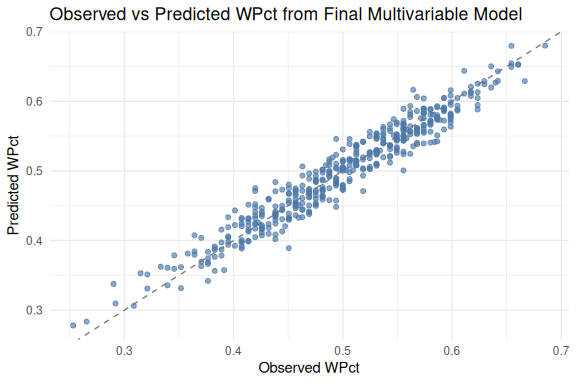

``` r
ggplot(teams_22_model, aes(x = bill_pred, y = final_pred)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(alpha = 0.65, color = "#4C78A8") +
  labs(
    title = "Predictions from Bill James and Final Multivariable Models",
    x = "Bill James predicted WPct",
    y = "Final model predicted WPct"
  ) +
  theme_minimal()
```

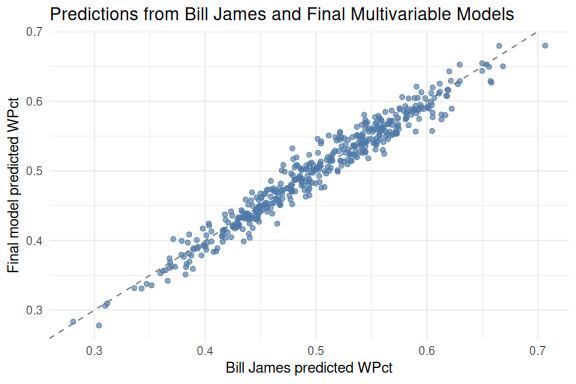

## Python

``` python
import numpy as np
import pandas as pd
import pylahman
import matplotlib.pyplot as plt
import statsmodels.api as sm

def get_pylahman_table(name):
    for candidate in (name, name.lower(), name.capitalize(), name.upper()):
        if hasattr(pylahman, candidate):
            return getattr(pylahman, candidate)()
    raise AttributeError(f"pylahman has no table named {name}")

Teams_22_py = get_pylahman_table("Teams")
available_end_year_py = min(2025, int(Teams_22_py["yearID"].max()))

candidate_predictors_py = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
    "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
    "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

teams_22_py = (
    Teams_22_py
    .loc[
        (Teams_22_py["yearID"] >= 2010)
        & (Teams_22_py["yearID"] <= available_end_year_py)
        & (Teams_22_py["yearID"] != 2020)
    ]
    .rename(columns={"R": "RS"})
    .copy()
)

numeric_cols_22_py = ["W", "L", "RS", "RA"] + [
    col for col in candidate_predictors_py
    if col in teams_22_py.columns
]

for col in numeric_cols_22_py:
    teams_22_py[col] = pd.to_numeric(teams_22_py[col], errors="coerce")

teams_22_py["games"] = teams_22_py["W"] + teams_22_py["L"]
teams_22_py["WPct"] = teams_22_py["W"] / teams_22_py["games"]
teams_22_py["logRS"] = np.log(teams_22_py["RS"])
teams_22_py["logRA"] = np.log(teams_22_py["RA"])
teams_22_py["log_run_ratio"] = np.log(teams_22_py["RS"] / teams_22_py["RA"])

missing_predictors_py = [
    predictor for predictor in candidate_predictors_py
    if predictor not in teams_22_py.columns
]
print("Missing predictors:", missing_predictors_py)
```

    Missing predictors: ['X2B', 'X3B']

``` python
model_predictors_py = [
    predictor for predictor in candidate_predictors_py
    if predictor in teams_22_py.columns
]

needed_cols_py = [
    "yearID", "teamID", "W", "L", "games", "WPct", "log_run_ratio"
] + model_predictors_py

teams_22_model_py = (
    teams_22_py[needed_cols_py]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)
teams_22_model_py = teams_22_model_py.loc[
    (teams_22_model_py["games"] > 0)
    & (teams_22_model_py["W"] > 0)
    & (teams_22_model_py["L"] > 0)
].copy()

print(pd.DataFrame({
    "first_year": [teams_22_model_py["yearID"].min()],
    "last_year": [teams_22_model_py["yearID"].max()],
    "n": [len(teams_22_model_py)],
    "mean_WPct": [teams_22_model_py["WPct"].mean()]
}))
```

       first_year  last_year    n  mean_WPct
    0        2010       2024  420   0.499992

``` python
endog_22_py = teams_22_model_py[["W", "L"]].astype(float).to_numpy()

def fit_binom_model(terms, intercept=True):
    if len(terms) == 0:
        x = pd.DataFrame(index=teams_22_model_py.index)
    else:
        x = teams_22_model_py[terms].astype(float).copy()
    if intercept:
        x = sm.add_constant(x, has_constant="add")
    return sm.GLM(endog_22_py, x, family=sm.families.Binomial()).fit(maxiter=200)

full_model_py = fit_binom_model(model_predictors_py, intercept=True)

def stepwise_aic(initial_terms, all_terms):
    selected = list(initial_terms)
    current_model = fit_binom_model(selected, intercept=True)
    current_aic = current_model.aic
    improved = True

    while improved:
        improved = False
        candidates = []

        remaining = [term for term in all_terms if term not in selected]
        for term in remaining:
            trial_terms = selected + [term]
            try:
                trial_model = fit_binom_model(trial_terms, intercept=True)
                candidates.append(("add", term, trial_terms, trial_model, trial_model.aic))
            except Exception:
                pass

        for term in selected:
            trial_terms = [x for x in selected if x != term]
            try:
                trial_model = fit_binom_model(trial_terms, intercept=True)
                candidates.append(("drop", term, trial_terms, trial_model, trial_model.aic))
            except Exception:
                pass

        if candidates:
            best = min(candidates, key=lambda item: item[4])
            if best[4] + 1e-7 < current_aic:
                selected = best[2]
                current_model = best[3]
                current_aic = best[4]
                improved = True

    return current_model, selected

step_model_py, selected_terms_py = stepwise_aic(
    model_predictors_py,
    model_predictors_py
)

print("Selected terms:", selected_terms_py)
```

    Selected terms: ['logRS', 'logRA', 'CG', 'SHO', 'SV']

``` python
step_coef_py = pd.DataFrame({
    "term": step_model_py.params.index,
    "estimate": step_model_py.params.values,
    "std_error": step_model_py.bse.values,
    "statistic": step_model_py.tvalues.values,
    "p_value": step_model_py.pvalues.values
})
step_coef_py["conf_low"] = step_coef_py["estimate"] - 1.96 * step_coef_py["std_error"]
step_coef_py["conf_high"] = step_coef_py["estimate"] + 1.96 * step_coef_py["std_error"]

print(step_coef_py)
```

        term  estimate  std_error  statistic        p_value  conf_low  conf_high
    0  const -2.480069   0.865489  -2.865514   4.163334e-03 -4.176427  -0.783712
    1  logRS  1.616907   0.073587  21.972845  5.238220e-107  1.472677   1.761137
    2  logRA -1.315910   0.105267 -12.500661   7.403320e-36 -1.522234  -1.109586
    3     CG  0.004443   0.003096   1.435257   1.512138e-01 -0.001625   0.010512
    4    SHO  0.004314   0.002610   1.652533   9.842586e-02 -0.000803   0.009430
    5     SV  0.010791   0.001360   7.935554   2.095579e-15  0.008126   0.013456

``` python
weak_terms_py = (
    step_coef_py
    .loc[
        (step_coef_py["term"] != "const")
        & (step_coef_py["p_value"] > 0.10),
        "term"
    ]
    .tolist()
)
print("Weak terms by Wald p-value > 0.10:", weak_terms_py)
```

    Weak terms by Wald p-value > 0.10: ['CG']

``` python
if weak_terms_py:
    refined_terms_py = [
        term for term in selected_terms_py
        if term not in weak_terms_py
    ]
    refined_model_py = fit_binom_model(refined_terms_py, intercept=True)
else:
    refined_terms_py = selected_terms_py
    refined_model_py = step_model_py

if refined_model_py.aic <= step_model_py.aic + 2:
    final_model_py = refined_model_py
    final_terms_py = refined_terms_py
else:
    final_model_py = step_model_py
    final_terms_py = selected_terms_py

print("Final terms:", final_terms_py)
```

    Final terms: ['logRS', 'logRA', 'SHO', 'SV']

``` python
final_coef_py = pd.DataFrame({
    "term": final_model_py.params.index,
    "estimate": final_model_py.params.values,
    "std_error": final_model_py.bse.values,
    "statistic": final_model_py.tvalues.values,
    "p_value": final_model_py.pvalues.values
})
final_coef_py["conf_low"] = final_coef_py["estimate"] - 1.96 * final_coef_py["std_error"]
final_coef_py["conf_high"] = final_coef_py["estimate"] + 1.96 * final_coef_py["std_error"]

print(final_coef_py)
```

        term  estimate  std_error  statistic        p_value  conf_low  conf_high
    0  const -2.154903   0.835340  -2.579673   9.889380e-03 -3.792169  -0.517638
    1  logRS  1.608600   0.073355  21.928891  1.377426e-106  1.464823   1.752376
    2  logRA -1.353042   0.102055 -13.257977   4.056929e-40 -1.553070  -1.153014
    3    SHO  0.004656   0.002599   1.791242   7.325445e-02 -0.000439   0.009751
    4     SV  0.010358   0.001326   7.812528   5.605239e-15  0.007759   0.012956

``` python
bill_james_glm_py = sm.GLM(
    endog_22_py,
    teams_22_model_py[["log_run_ratio"]].astype(float),
    family=sm.families.Binomial()
).fit()

def predict_for_terms(model, terms, intercept=True):
    if len(terms) == 0:
        x = pd.DataFrame(index=teams_22_model_py.index)
    else:
        x = teams_22_model_py[terms].astype(float).copy()
    if intercept:
        x = sm.add_constant(x, has_constant="add")
    return model.predict(x)

def model_rmse_py(model, terms, intercept=True):
    pred = predict_for_terms(model, terms, intercept=intercept)
    return np.sqrt(np.mean((teams_22_model_py["WPct"] - pred) ** 2))

model_comparison_22_py = pd.DataFrame({
    "model": [
        "Bill James one-slope model",
        "Full multivariable model",
        "AIC stepwise model",
        "Final selected model"
    ],
    "df_model": [
        len(bill_james_glm_py.params),
        len(full_model_py.params),
        len(step_model_py.params),
        len(final_model_py.params)
    ],
    "AIC": [
        bill_james_glm_py.aic,
        full_model_py.aic,
        step_model_py.aic,
        final_model_py.aic
    ],
    "residual_deviance": [
        bill_james_glm_py.deviance,
        full_model_py.deviance,
        step_model_py.deviance,
        final_model_py.deviance
    ],
    "df_residual": [
        bill_james_glm_py.df_resid,
        full_model_py.df_resid,
        step_model_py.df_resid,
        final_model_py.df_resid
    ],
    "prediction_rmse": [
        model_rmse_py(bill_james_glm_py, ["log_run_ratio"], intercept=False),
        model_rmse_py(full_model_py, model_predictors_py, intercept=True),
        model_rmse_py(step_model_py, selected_terms_py, intercept=True),
        model_rmse_py(final_model_py, final_terms_py, intercept=True)
    ]
})

print(model_comparison_22_py)
```

                            model  df_model  ...  df_residual  prediction_rmse
    0  Bill James one-slope model         1  ...          419         0.024353
    1    Full multivariable model        22  ...          398         0.017921
    2          AIC stepwise model         6  ...          414         0.018830
    3        Final selected model         5  ...          415         0.019028

    [4 rows x 6 columns]

``` python
teams_22_model_py["bill_pred"] = predict_for_terms(
    bill_james_glm_py,
    ["log_run_ratio"],
    intercept=False
)
teams_22_model_py["final_pred"] = predict_for_terms(
    final_model_py,
    final_terms_py,
    intercept=True
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0.25, 0.75], [0.25, 0.75], linestyle="--", color="gray")
ax.scatter(teams_22_model_py["WPct"], teams_22_model_py["final_pred"], alpha=0.65)
ax.set_title("Observed vs Predicted WPct from Final Multivariable Model")
ax.set_xlabel("Observed WPct")
ax.set_ylabel("Predicted WPct")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

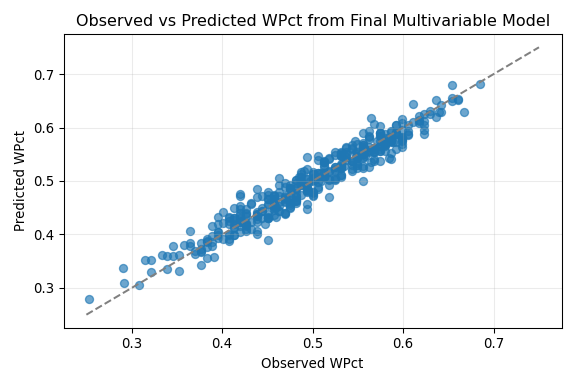

``` python
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0.25, 0.75], [0.25, 0.75], linestyle="--", color="gray")
ax.scatter(teams_22_model_py["bill_pred"], teams_22_model_py["final_pred"], alpha=0.65)
ax.set_title("Predictions from Bill James and Final Multivariable Models")
ax.set_xlabel("Bill James predicted WPct")
ax.set_ylabel("Final model predicted WPct")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

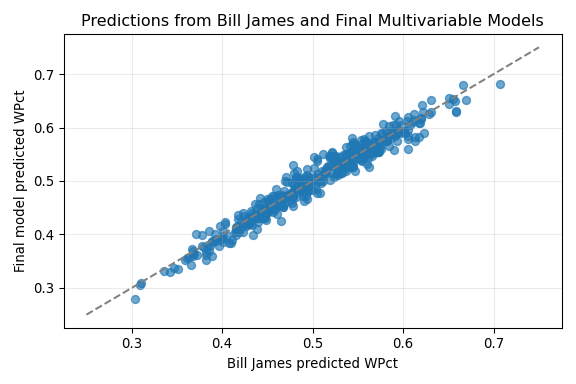

AIC 기준 단계별 변수선택은 많은 후보 변수 중에서 승률 설명에 도움이 되는
변수를 남긴다. 다만 AIC는 예측 성능과 모형 복잡도의 균형을 보는
기준이므로, 선택된 모든 변수가 반드시 개별적으로 강한 가설검정 결과를
가져야 하는 것은 아니다. 그래서 선택 후에는 R에서는 `drop1()`의
likelihood-ratio 검정, Python에서는 Wald p-value를 확인하고, p-value가
큰 변수를 제거했을 때 AIC가 크게 나빠지지 않는 경우에는 더 단순한 모형을
최종 모형으로 삼았다.

최종 다변량 모형은 Bill James의 한 변수 모형보다 더 많은 경기 요소를
사용하므로 AIC와 예측 RMSE가 개선될 수 있다. 하지만 선택된 변수 중
다수는 득점과 실점을 구성하거나 그와 강하게 관련된 변수이므로, 최종
모형이 단순 Bill James 모형보다 해석이 항상 더 명확하다고 보기는 어렵다.
따라서 Bill James 모형은 간결하고 해석하기 쉬운 기준 모형이고, stepwise
다변량 모형은 예측 정확도를 높이기 위한 확장 모형으로 해석하는 것이
적절하다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

`W`는 한 시즌의 승리 횟수이므로 포아송 회귀에서는 경기 수 차이를
보정하기 위해 `offset(log(games))`를 포함하였다. 즉 모형은 승리 수
자체를 설명하지만, 평균 승리 수가 경기 수에 비례한다고 두어 승률 모형과
비교할 수 있게 만들었다. 후보 설명변수는 문제 2-2와 동일하게 사용하였다.

## R

``` r
library(tidyverse)
library(Lahman)

available_end_year <- min(2025, max(Lahman::Teams$yearID, na.rm = TRUE))

candidate_predictors <- c(
  "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
  "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
  "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
)

teams_23 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= available_end_year,
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    games = W + L,
    WPct = W / games,
    logRS = log(RS),
    logRA = log(RA),
    log_run_ratio = log(RS / RA)
  )

model_predictors_23 <- intersect(candidate_predictors, names(teams_23))

teams_23_model <- teams_23 %>%
  select(
    yearID, teamID, W, L, games, WPct, log_run_ratio,
    all_of(model_predictors_23)
  ) %>%
  filter(games > 0, W >= 0, L >= 0) %>%
  drop_na()

teams_23_model %>%
  summarize(
    first_year = min(yearID),
    last_year = max(yearID),
    n = n(),
    mean_games = mean(games),
    mean_W = mean(W),
    mean_WPct = mean(WPct)
  )
```

      first_year last_year   n mean_games   mean_W mean_WPct
    1       2010      2025 450   161.9733 80.98667 0.4999927

``` r
poisson_full_formula <- reformulate(
  c(model_predictors_23, "offset(log(games))"),
  response = "W"
)

poisson_full <- glm(
  poisson_full_formula,
  data = teams_23_model,
  family = poisson()
)

poisson_step <- step(
  poisson_full,
  direction = "both",
  trace = 0
)

poisson_step_terms <- attr(terms(poisson_step), "term.labels")
poisson_step_terms
```

    [1] "logRS" "ERA"   "CG"    "SHO"   "FP"    "SV"   

``` r
poisson_drop_table <- as.data.frame(drop1(poisson_step, test = "Chisq")) %>%
  rownames_to_column("term") %>%
  filter(term != "<none>")

poisson_drop_table
```

       term Df  Deviance      AIC        LRT     Pr(>Chi)
    1 logRS  1 304.98445 3116.844 244.499171 4.108871e-55
    2   ERA  1 138.41879 2950.278  77.933508 1.065681e-18
    3    CG  1  62.49273 2874.352   2.007444 1.565288e-01
    4   SHO  1  62.53185 2874.391   2.046567 1.525499e-01
    5    FP  1  62.57751 2874.437   2.092225 1.480503e-01
    6    SV  1  98.09218 2909.952  37.606900 8.653780e-10

``` r
poisson_weak_terms <- poisson_drop_table %>%
  filter(!is.na(`Pr(>Chi)`), `Pr(>Chi)` > 0.10) %>%
  pull(term)

poisson_weak_terms
```

    [1] "CG"  "SHO" "FP" 

``` r
poisson_refined_terms <- setdiff(poisson_step_terms, poisson_weak_terms)

poisson_refined <- glm(
  reformulate(
    c(poisson_refined_terms, "offset(log(games))"),
    response = "W"
  ),
  data = teams_23_model,
  family = poisson()
)

poisson_final <- if (AIC(poisson_refined) <= AIC(poisson_step) + 2) {
  poisson_refined
} else {
  poisson_step
}

poisson_final_terms <- attr(terms(poisson_final), "term.labels")
poisson_final_terms
```

    [1] "logRS" "ERA"   "SV"   

``` r
poisson_final_coef <- as.data.frame(summary(poisson_final)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

poisson_final_coef
```

             term     estimate    std_error  statistic      p_value     conf_low
    1 (Intercept) -5.515205109 0.3304775704 -16.688591 1.586706e-62 -6.162929245
    2       logRS  0.801563686 0.0495352792  16.181673 6.792350e-59  0.704476323
    3         ERA -0.163946800 0.0124350656 -13.184233 1.081486e-39 -0.188319081
    4          SV  0.005375149 0.0009051248   5.938573 2.875143e-09  0.003601137
         conf_high
    1 -4.867480974
    2  0.898651050
    3 -0.139574519
    4  0.007149161

``` r
poisson_dispersion <- sum(residuals(poisson_final, type = "pearson")^2) /
  df.residual(poisson_final)

poisson_dispersion
```

    [1] 0.150495

``` r
poisson_rmse <- function(model) {
  pred_wpct <- fitted(model) / teams_23_model$games
  sqrt(mean((teams_23_model$WPct - pred_wpct)^2))
}

binomial_final_rmse <- if (exists("final_model") && exists("teams_22_model")) {
  sqrt(mean((teams_22_model$WPct - fitted(final_model))^2))
} else {
  NA_real_
}

poisson_comparison <- tibble(
  model = c(
    "Problem 2-2 final binomial logistic",
    "Poisson full model",
    "Poisson AIC stepwise model",
    "Poisson final model"
  ),
  df_model = c(
    if (exists("final_model")) length(coef(final_model)) else NA_integer_,
    length(coef(poisson_full)),
    length(coef(poisson_step)),
    length(coef(poisson_final))
  ),
  AIC = c(
    if (exists("final_model")) AIC(final_model) else NA_real_,
    AIC(poisson_full),
    AIC(poisson_step),
    AIC(poisson_final)
  ),
  prediction_rmse_WPct = c(
    binomial_final_rmse,
    poisson_rmse(poisson_full),
    poisson_rmse(poisson_step),
    poisson_rmse(poisson_final)
  )
)

poisson_comparison
```

    # A tibble: 4 × 4
      model                               df_model   AIC prediction_rmse_WPct
      <chr>                                  <int> <dbl>                <dbl>
    1 Problem 2-2 final binomial logistic        5 2602.               0.0191
    2 Poisson full model                        24 2904.               0.0192
    3 Poisson AIC stepwise model                 7 2874.               0.0199
    4 Poisson final model                        4 2875.               0.0210

``` r
teams_23_model <- teams_23_model %>%
  mutate(
    poisson_final_pred_WPct = fitted(poisson_final) / games
  )

ggplot(teams_23_model, aes(x = WPct, y = poisson_final_pred_WPct)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(alpha = 0.65, color = "#4C78A8") +
  labs(
    title = "Observed vs Predicted WPct from Final Poisson Model",
    x = "Observed WPct",
    y = "Poisson predicted WPct"
  ) +
  theme_minimal()
```

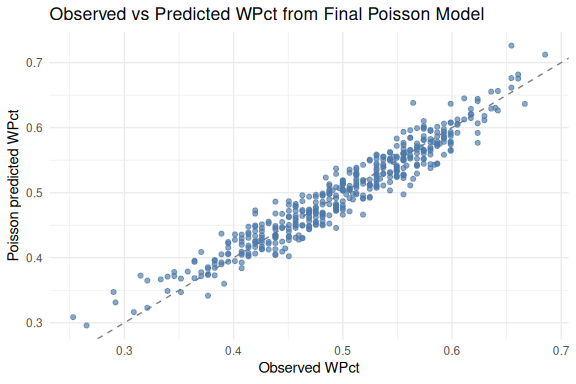

``` r
fit_nb_safely <- function(formula, data) {
  warnings_seen <- character()
  result <- withCallingHandlers(
    tryCatch(
      MASS::glm.nb(
        formula,
        data = data,
        control = glm.control(maxit = 100)
      ),
      error = function(e) e
    ),
    warning = function(w) {
      warnings_seen <<- c(warnings_seen, conditionMessage(w))
      invokeRestart("muffleWarning")
    }
  )

  list(
    fit = result,
    warnings = unique(warnings_seen)
  )
}

nb_full_result <- fit_nb_safely(poisson_full_formula, teams_23_model)

nb_final_result <- fit_nb_safely(
  reformulate(
    c(poisson_final_terms, "offset(log(games))"),
    response = "W"
  ),
  teams_23_model
)

nb_status <- function(result, label) {
  fit <- result$fit
  warnings_text <- if (length(result$warnings) == 0) {
    NA_character_
  } else {
    str_c(head(result$warnings, 3), collapse = " / ")
  }

  tibble(
    model = label,
    success = !inherits(fit, "error"),
    theta = if (!inherits(fit, "error")) fit$theta else NA_real_,
    AIC = if (!inherits(fit, "error")) AIC(fit) else NA_real_,
    error = if (inherits(fit, "error")) conditionMessage(fit) else NA_character_,
    warnings = warnings_text
  )
}

nb_diagnostics <- bind_rows(
  nb_status(nb_full_result, "Negative binomial full model"),
  nb_status(nb_final_result, "Negative binomial with final Poisson terms")
)

nb_diagnostics
```

    # A tibble: 2 × 6
      model                                     success   theta   AIC error warnings
      <chr>                                     <lgl>     <dbl> <dbl> <chr> <chr>   
    1 Negative binomial full model              TRUE    9.28e 9 2906. <NA>  iterati…
    2 Negative binomial with final Poisson ter… TRUE    1.40e10 2877. <NA>  iterati…

``` r
if (!inherits(nb_final_result$fit, "error")) {
  as.data.frame(summary(nb_final_result$fit)$coefficients) %>%
    rownames_to_column("term") %>%
    rename(
      estimate = Estimate,
      std_error = `Std. Error`,
      statistic = `z value`,
      p_value = `Pr(>|z|)`
    )
}
```

             term     estimate   std_error  statistic      p_value
    1 (Intercept) -5.515205110 0.330477660 -16.688587 1.586827e-62
    2       logRS  0.801563686 0.049535292  16.181669 6.792806e-59
    3         ERA -0.163946800 0.012435069 -13.184229 1.081544e-39
    4          SV  0.005375149 0.000905125   5.938571 2.875167e-09

## Python

``` python
import warnings
import numpy as np
import pandas as pd
import pylahman
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

def get_pylahman_table(name):
    for candidate in (name, name.lower(), name.capitalize(), name.upper()):
        if hasattr(pylahman, candidate):
            return getattr(pylahman, candidate)()
    raise AttributeError(f"pylahman has no table named {name}")

Teams_23_py = get_pylahman_table("Teams")
available_end_year_py = min(2025, int(Teams_23_py["yearID"].max()))

candidate_predictors_py = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO",
    "CS", "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA",
    "HRA", "BBA", "SOA", "E", "DP", "FP", "SV"
]

teams_23_py = (
    Teams_23_py
    .loc[
        (Teams_23_py["yearID"] >= 2010)
        & (Teams_23_py["yearID"] <= available_end_year_py)
        & (Teams_23_py["yearID"] != 2020)
    ]
    .rename(columns={"R": "RS"})
    .copy()
)

numeric_cols = ["W", "L", "RS", "RA"] + [
    col for col in candidate_predictors_py
    if col in teams_23_py.columns
]

for col in numeric_cols:
    teams_23_py[col] = pd.to_numeric(teams_23_py[col], errors="coerce")

teams_23_py["games"] = teams_23_py["W"] + teams_23_py["L"]
teams_23_py["WPct"] = teams_23_py["W"] / teams_23_py["games"]
teams_23_py["logRS"] = np.log(teams_23_py["RS"])
teams_23_py["logRA"] = np.log(teams_23_py["RA"])
teams_23_py["log_run_ratio"] = np.log(teams_23_py["RS"] / teams_23_py["RA"])

model_predictors_23_py = [
    predictor for predictor in candidate_predictors_py
    if predictor in teams_23_py.columns
]

needed_cols_23_py = [
    "yearID", "teamID", "W", "L", "games", "WPct", "log_run_ratio"
] + model_predictors_23_py

teams_23_model_py = (
    teams_23_py[needed_cols_23_py]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)
teams_23_model_py = teams_23_model_py.loc[
    (teams_23_model_py["games"] > 0)
    & (teams_23_model_py["W"] >= 0)
    & (teams_23_model_py["L"] >= 0)
].copy()

print(pd.DataFrame({
    "first_year": [teams_23_model_py["yearID"].min()],
    "last_year": [teams_23_model_py["yearID"].max()],
    "n": [len(teams_23_model_py)],
    "mean_games": [teams_23_model_py["games"].mean()],
    "mean_W": [teams_23_model_py["W"].mean()],
    "mean_WPct": [teams_23_model_py["WPct"].mean()]
}))
```

       first_year  last_year    n  mean_games     mean_W  mean_WPct
    0        2010       2024  420  161.971429  80.985714   0.499992

``` python
y_wins_py = teams_23_model_py["W"].astype(float).to_numpy()
offset_games_py = np.log(teams_23_model_py["games"].astype(float).to_numpy())

def make_exog(terms, intercept=True):
    if len(terms) == 0:
        x = pd.DataFrame(index=teams_23_model_py.index)
    else:
        x = teams_23_model_py[terms].astype(float).copy()

    if intercept:
        x = sm.add_constant(x, has_constant="add")

    return x

def fit_poisson_model(terms):
    return sm.GLM(
        y_wins_py,
        make_exog(terms, intercept=True),
        family=sm.families.Poisson(),
        offset=offset_games_py
    ).fit(maxiter=200)

poisson_full_py = fit_poisson_model(model_predictors_23_py)

def stepwise_aic_poisson(initial_terms, all_terms):
    selected = list(initial_terms)
    current_model = fit_poisson_model(selected)
    current_aic = current_model.aic
    improved = True

    while improved:
        improved = False
        candidates = []

        remaining = [term for term in all_terms if term not in selected]
        for term in remaining:
            trial_terms = selected + [term]
            try:
                trial_model = fit_poisson_model(trial_terms)
                candidates.append(("add", term, trial_terms, trial_model, trial_model.aic))
            except Exception:
                pass

        for term in selected:
            trial_terms = [x for x in selected if x != term]
            try:
                trial_model = fit_poisson_model(trial_terms)
                candidates.append(("drop", term, trial_terms, trial_model, trial_model.aic))
            except Exception:
                pass

        if candidates:
            best = min(candidates, key=lambda item: item[4])
            if best[4] + 1e-7 < current_aic:
                selected = best[2]
                current_model = best[3]
                current_aic = best[4]
                improved = True

    return current_model, selected

poisson_step_py, poisson_step_terms_py = stepwise_aic_poisson(
    model_predictors_23_py,
    model_predictors_23_py
)

print("Poisson stepwise terms:", poisson_step_terms_py)
```

    Poisson stepwise terms: ['logRS', 'ERA', 'CG', 'E', 'SV']

``` python
poisson_step_coef_py = pd.DataFrame({
    "term": poisson_step_py.params.index,
    "estimate": poisson_step_py.params.values,
    "std_error": poisson_step_py.bse.values,
    "statistic": poisson_step_py.tvalues.values,
    "p_value": poisson_step_py.pvalues.values
})
poisson_step_coef_py["conf_low"] = (
    poisson_step_coef_py["estimate"] - 1.96 * poisson_step_coef_py["std_error"]
)
poisson_step_coef_py["conf_high"] = (
    poisson_step_coef_py["estimate"] + 1.96 * poisson_step_coef_py["std_error"]
)

print(poisson_step_coef_py)
```

        term  estimate  std_error  statistic       p_value  conf_low  conf_high
    0  const -5.462974   0.357360 -15.287013  9.333331e-53 -6.163401  -4.762548
    1  logRS  0.794483   0.051943  15.295433  8.201384e-53  0.692676   0.896290
    2    ERA -0.155979   0.013897 -11.224272  3.099279e-29 -0.183216  -0.128742
    3     CG  0.003342   0.002117   1.578543  1.144409e-01 -0.000808   0.007492
    4      E -0.000592   0.000372  -1.591209  1.115625e-01 -0.001320   0.000137
    5     SV  0.005539   0.000952   5.820532  5.866050e-09  0.003674   0.007405

``` python
poisson_weak_terms_py = (
    poisson_step_coef_py
    .loc[
        (poisson_step_coef_py["term"] != "const")
        & (poisson_step_coef_py["p_value"] > 0.10),
        "term"
    ]
    .tolist()
)

print("Weak Poisson terms by Wald p-value > 0.10:", poisson_weak_terms_py)
```

    Weak Poisson terms by Wald p-value > 0.10: ['CG', 'E']

``` python
poisson_refined_terms_py = [
    term for term in poisson_step_terms_py
    if term not in poisson_weak_terms_py
]
poisson_refined_py = fit_poisson_model(poisson_refined_terms_py)

if poisson_refined_py.aic <= poisson_step_py.aic + 2:
    poisson_final_py = poisson_refined_py
    poisson_final_terms_py = poisson_refined_terms_py
else:
    poisson_final_py = poisson_step_py
    poisson_final_terms_py = poisson_step_terms_py

print("Poisson final terms:", poisson_final_terms_py)
```

    Poisson final terms: ['logRS', 'ERA', 'SV']

``` python
poisson_final_coef_py = pd.DataFrame({
    "term": poisson_final_py.params.index,
    "estimate": poisson_final_py.params.values,
    "std_error": poisson_final_py.bse.values,
    "statistic": poisson_final_py.tvalues.values,
    "p_value": poisson_final_py.pvalues.values
})
poisson_final_coef_py["conf_low"] = (
    poisson_final_coef_py["estimate"] - 1.96 * poisson_final_coef_py["std_error"]
)
poisson_final_coef_py["conf_high"] = (
    poisson_final_coef_py["estimate"] + 1.96 * poisson_final_coef_py["std_error"]
)

print(poisson_final_coef_py)
```

        term  estimate  std_error  statistic       p_value  conf_low  conf_high
    0  const -5.522675   0.338151 -16.331987  5.844935e-60 -6.185450  -4.859899
    1  logRS  0.805130   0.050664  15.891639  7.240894e-57  0.705829   0.904431
    2    ERA -0.166418   0.012837 -12.963409  1.972811e-38 -0.191579  -0.141256
    3     SV  0.005221   0.000924   5.650425  1.600516e-08  0.003410   0.007032

``` python
poisson_dispersion_py = (
    np.sum(poisson_final_py.resid_pearson ** 2) / poisson_final_py.df_resid
)
print(pd.DataFrame({"poisson_pearson_dispersion": [poisson_dispersion_py]}))
```

       poisson_pearson_dispersion
    0                     0.14848

``` python
def poisson_rmse_py(model, terms):
    pred_wpct = model.predict(make_exog(terms, intercept=True), offset=offset_games_py) / (
        teams_23_model_py["games"].to_numpy()
    )
    return np.sqrt(np.mean((teams_23_model_py["WPct"] - pred_wpct) ** 2))

binomial_final_aic_py = (
    final_model_py.aic
    if "final_model_py" in globals()
    else np.nan
)
binomial_final_rmse_py = (
    model_comparison_22_py
    .loc[
        model_comparison_22_py["model"].eq("Final selected model"),
        "prediction_rmse"
    ]
    .iloc[0]
    if "model_comparison_22_py" in globals()
    else np.nan
)

poisson_comparison_py = pd.DataFrame({
    "model": [
        "Problem 2-2 final binomial logistic",
        "Poisson full model",
        "Poisson AIC stepwise model",
        "Poisson final model"
    ],
    "df_model": [
        len(final_model_py.params) if "final_model_py" in globals() else np.nan,
        len(poisson_full_py.params),
        len(poisson_step_py.params),
        len(poisson_final_py.params)
    ],
    "AIC": [
        binomial_final_aic_py,
        poisson_full_py.aic,
        poisson_step_py.aic,
        poisson_final_py.aic
    ],
    "prediction_rmse_WPct": [
        binomial_final_rmse_py,
        poisson_rmse_py(poisson_full_py, model_predictors_23_py),
        poisson_rmse_py(poisson_step_py, poisson_step_terms_py),
        poisson_rmse_py(poisson_final_py, poisson_final_terms_py)
    ]
})

print(poisson_comparison_py)
```

                                     model  ...  prediction_rmse_WPct
    0  Problem 2-2 final binomial logistic  ...              0.019028
    1                   Poisson full model  ...              0.019149
    2           Poisson AIC stepwise model  ...              0.020131
    3                  Poisson final model  ...              0.020945

    [4 rows x 4 columns]

``` python
teams_23_model_py["poisson_final_pred_WPct"] = (
    poisson_final_py.predict(
        make_exog(poisson_final_terms_py, intercept=True),
        offset=offset_games_py
    )
    / teams_23_model_py["games"]
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0.25, 0.75], [0.25, 0.75], linestyle="--", color="gray")
ax.scatter(
    teams_23_model_py["WPct"],
    teams_23_model_py["poisson_final_pred_WPct"],
    alpha=0.65,
    color="#4C78A8"
)
ax.set_title("Observed vs Predicted WPct from Final Poisson Model")
ax.set_xlabel("Observed WPct")
ax.set_ylabel("Poisson predicted WPct")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

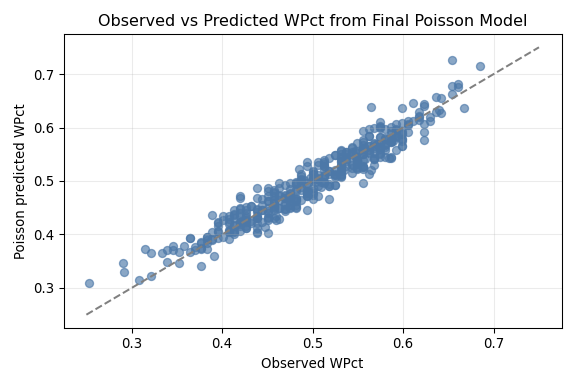

``` python
def fit_negative_binomial_safely(terms):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            model = NegativeBinomial(
                y_wins_py,
                make_exog(terms, intercept=True),
                offset=offset_games_py
            ).fit(maxiter=200, disp=False)
            error = None
        except Exception as exc:
            model = None
            error = exc

    return model, caught, error

nb_full_py, nb_full_warnings_py, nb_full_error_py = fit_negative_binomial_safely(
    model_predictors_23_py
)
nb_final_py, nb_final_warnings_py, nb_final_error_py = fit_negative_binomial_safely(
    poisson_final_terms_py
)

def summarize_nb_fit(label, model, caught, error):
    warning_text = " / ".join(
        sorted({str(warning.message) for warning in caught})[:3]
    )
    if warning_text == "":
        warning_text = np.nan

    return {
        "model": label,
        "success": model is not None,
        "converged": (
            model.mle_retvals.get("converged")
            if model is not None
            else np.nan
        ),
        "alpha": (
            model.params.get("alpha", np.nan)
            if model is not None
            else np.nan
        ),
        "AIC": model.aic if model is not None else np.nan,
        "error": str(error) if error is not None else np.nan,
        "warnings": warning_text
    }

nb_diagnostics_py = pd.DataFrame([
    summarize_nb_fit(
        "Negative binomial full model",
        nb_full_py,
        nb_full_warnings_py,
        nb_full_error_py
    ),
    summarize_nb_fit(
        "Negative binomial with final Poisson terms",
        nb_final_py,
        nb_final_warnings_py,
        nb_final_error_py
    )
])

print(nb_diagnostics_py)
```

                                            model  ...                                           warnings
    0                Negative binomial full model  ...  Inverting hessian failed, no bse or cov_params...
    1  Negative binomial with final Poisson terms  ...  Inverting hessian failed, no bse or cov_params...

    [2 rows x 7 columns]

``` python
if nb_final_py is not None:
    print(nb_final_py.params)
```

    const   -5.523555e+00
    logRS    8.052582e-01
    ERA     -1.664107e-01
    SV       5.221077e-03
    alpha    8.626869e-09
    dtype: float64

포아송 모형은 `W`를 count로 다루지만, `games`를 offset으로 넣었기 때문에
사실상 경기당 승리율을 설명하는 모형으로 해석할 수 있다. 단계별 선택 후
남은 변수들은 대체로 득점 생산(`logRS`)과 실점 억제(`ERA`),
세이브(`SV`)처럼 승률과 직접 연결되는 지표들이다. 포아송 최종 모형의
예측은 문제 2-2의 이항 로지스틱 모형과 비슷한 방향을 보이지만, 승리 수는
시즌 경기 수 안에서 실패 수(`L`)와 함께 결정되므로 이론적으로는
`cbind(W, L)`을 사용한 문제 2-2의 이항 모형이 더 자연스럽다.

포아송 최종 모형의 Pearson dispersion은 보통 1보다 훨씬 작게 나타난다.
이는 승리 수가 일반적인 포아송 count처럼 평균만큼 자유롭게 분산되는 것이
아니라, 한 시즌에 약 162경기라는 상한과 `W + L = games`라는 제약을 받기
때문이다. 따라서 포아송의 등분산 가정도 완전히 맞지는 않는다.

음이항 회귀는 포아송보다 분산이 큰 과산포 count를 다루기 위한 모형이다.
그러나 이 자료에서는 과산포가 아니라 오히려 underdispersion이 나타나므로
음이항 분산모수 추정이 불안정하다. R에서는 전체 후보 변수를 넣은
`glm.nb()`가 `theta` 추정 반복 한계와 `NaN` 경고 뒤 오류를 낼 수 있고,
더 작은 모형에서는 `theta`가 매우 큰 값으로 밀려 포아송 모형과 거의
같아진다. Python에서도 음이항 모형은 수렴하지 않거나 `alpha`가 0에
가까워지는 방식으로 같은 현상을 보인다. 따라서 이 문제에서는 음이항
모형을 최종 모형으로 사용하는 것이 적절하지 않다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

주어진 식은 로짓을 취하면 선형 로지스틱 모형으로 바뀐다.

$$\text{logit}(WPct_{i,t})
=
\left\{ k + g I(1994 \le t \le 2005) \right\}
\log(RS_{i,t}/RA_{i,t}).$$

따라서 최근 시대를 기준으로 두면 `log_run_ratio = log(RS / RA)`의 계수는
최근 시대의 `k`이고, `steroid_era * log_run_ratio`의 계수는 스테로이드
시대와 최근 시대의 차이인 `g`이다. 검정할 가설은 $H_0: g = 0$이다.

## R

``` r
library(tidyverse)
library(Lahman)

available_end_year <- min(2025, max(Lahman::Teams$yearID, na.rm = TRUE))

teams_24 <- Lahman::Teams %>%
  filter(
    (
      yearID >= 1994 & yearID <= 2005
    ) |
      (
        yearID >= 2010 & yearID <= available_end_year
      ),
    yearID != 2020
  ) %>%
  rename(RS = R) %>%
  mutate(
    games = W + L,
    WPct = W / games,
    log_run_ratio = log(RS / RA),
    steroid_era = if_else(yearID >= 1994 & yearID <= 2005, 1, 0),
    era = if_else(steroid_era == 1, "Steroid era", "Recent"),
    era = factor(era, levels = c("Recent", "Steroid era")),
    steroid_log_ratio = steroid_era * log_run_ratio
  ) %>%
  filter(
    games > 0,
    RS > 0,
    RA > 0,
    W > 0,
    L > 0
  ) %>%
  drop_na(W, L, log_run_ratio, steroid_log_ratio)

teams_24 %>%
  group_by(era) %>%
  summarize(
    first_year = min(yearID),
    last_year = max(yearID),
    n = n(),
    mean_WPct = mean(WPct),
    .groups = "drop"
  )
```

    # A tibble: 2 × 5
      era         first_year last_year     n mean_WPct
      <fct>            <int>     <int> <int>     <dbl>
    1 Recent            2010      2025   450     0.500
    2 Steroid era       1994      2005   352     0.500

``` r
common_k_model <- glm(
  cbind(W, L) ~ 0 + log_run_ratio,
  data = teams_24,
  family = binomial()
)

era_k_model <- glm(
  cbind(W, L) ~ 0 + log_run_ratio + steroid_log_ratio,
  data = teams_24,
  family = binomial()
)

era_k_coef <- as.data.frame(summary(era_k_model)$coefficients) %>%
  rownames_to_column("term") %>%
  rename(
    estimate = Estimate,
    std_error = `Std. Error`,
    statistic = `z value`,
    p_value = `Pr(>|z|)`
  ) %>%
  mutate(
    conf_low = estimate - qnorm(0.975) * std_error,
    conf_high = estimate + qnorm(0.975) * std_error
  )

era_k_coef
```

                   term  estimate  std_error statistic       p_value   conf_low
    1     log_run_ratio 1.7532035 0.04561729 38.432871 3.952525e-323 1.66379521
    2 steroid_log_ratio 0.1615666 0.07475132  2.161388  3.066536e-02 0.01505673
      conf_high
    1 1.8426117
    2 0.3080765

``` r
k_recent <- coef(era_k_model)[["log_run_ratio"]]
g_steroid <- coef(era_k_model)[["steroid_log_ratio"]]

k_estimates <- tibble(
  quantity = c("k_recent", "g", "k_steroid"),
  estimate = c(
    k_recent,
    g_steroid,
    k_recent + g_steroid
  )
)

k_estimates
```

    # A tibble: 3 × 2
      quantity  estimate
      <chr>        <dbl>
    1 k_recent     1.75 
    2 g            0.162
    3 k_steroid    1.91 

``` r
anova(common_k_model, era_k_model, test = "Chisq")
```

    Analysis of Deviance Table

    Model 1: cbind(W, L) ~ 0 + log_run_ratio
    Model 2: cbind(W, L) ~ 0 + log_run_ratio + steroid_log_ratio
      Resid. Df Resid. Dev Df Deviance Pr(>Chi)  
    1       801     320.36                       
    2       800     315.68  1   4.6746  0.03061 *
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

``` r
AIC(common_k_model, era_k_model)
```

                   df      AIC
    common_k_model  1 4735.398
    era_k_model     2 4732.723

``` r
prediction_grid <- expand_grid(
  log_run_ratio = seq(
    min(teams_24$log_run_ratio),
    max(teams_24$log_run_ratio),
    length.out = 200
  ),
  era = factor(c("Recent", "Steroid era"), levels = c("Recent", "Steroid era"))
) %>%
  mutate(
    steroid_era = if_else(era == "Steroid era", 1, 0),
    steroid_log_ratio = steroid_era * log_run_ratio
  ) %>%
  mutate(
    pred_WPct = as.numeric(
      predict(era_k_model, newdata = ., type = "response")
    )
  )

ggplot(teams_24, aes(x = log_run_ratio, y = WPct, color = era)) +
  geom_point(alpha = 0.45) +
  geom_line(
    data = prediction_grid,
    aes(y = pred_WPct),
    linewidth = 1.1
  ) +
  labs(
    title = "Bill James k by Era",
    x = "log(RS / RA)",
    y = "Winning percentage",
    color = "Era"
  ) +
  theme_minimal()
```

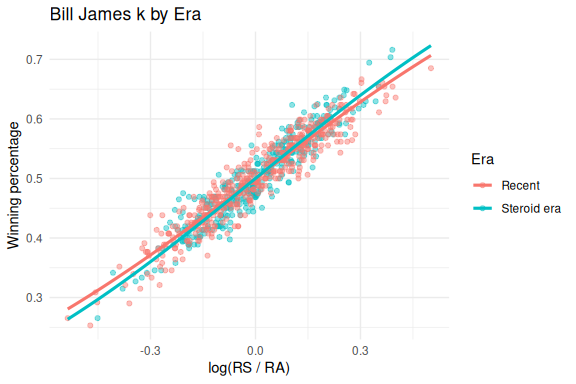

## Python

``` python
import numpy as np
import pandas as pd
import pylahman
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

def get_pylahman_table(name):
    for candidate in (name, name.lower(), name.capitalize(), name.upper()):
        if hasattr(pylahman, candidate):
            return getattr(pylahman, candidate)()
    raise AttributeError(f"pylahman has no table named {name}")

Teams_24_py = get_pylahman_table("Teams")
Teams_24_py["yearID"] = pd.to_numeric(Teams_24_py["yearID"], errors="coerce")
available_end_year_py = min(2025, int(Teams_24_py["yearID"].max()))

teams_24_py = (
    Teams_24_py
    .loc[
        (
            (Teams_24_py["yearID"] >= 1994)
            & (Teams_24_py["yearID"] <= 2005)
        )
        | (
            (Teams_24_py["yearID"] >= 2010)
            & (Teams_24_py["yearID"] <= available_end_year_py)
        )
    ]
    .loc[lambda df: df["yearID"] != 2020]
    .rename(columns={"R": "RS"})
    .copy()
)

for col in ["W", "L", "RS", "RA"]:
    teams_24_py[col] = pd.to_numeric(teams_24_py[col], errors="coerce")

teams_24_py["games"] = teams_24_py["W"] + teams_24_py["L"]
teams_24_py["WPct"] = teams_24_py["W"] / teams_24_py["games"]
teams_24_py["log_run_ratio"] = np.log(teams_24_py["RS"] / teams_24_py["RA"])
teams_24_py["steroid_era"] = (
    (teams_24_py["yearID"] >= 1994)
    & (teams_24_py["yearID"] <= 2005)
).astype(int)
teams_24_py["era"] = np.where(
    teams_24_py["steroid_era"].eq(1),
    "Steroid era",
    "Recent"
)
teams_24_py["steroid_log_ratio"] = (
    teams_24_py["steroid_era"] * teams_24_py["log_run_ratio"]
)

teams_24_py = (
    teams_24_py
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["W", "L", "games", "log_run_ratio", "steroid_log_ratio"])
    .copy()
)
teams_24_py = teams_24_py.loc[
    (teams_24_py["games"] > 0)
    & (teams_24_py["RS"] > 0)
    & (teams_24_py["RA"] > 0)
    & (teams_24_py["W"] > 0)
    & (teams_24_py["L"] > 0)
].copy()

era_summary_py = (
    teams_24_py
    .groupby("era", as_index=False)
    .agg(
        first_year=("yearID", "min"),
        last_year=("yearID", "max"),
        n=("teamID", "size"),
        mean_WPct=("WPct", "mean")
    )
)

print(era_summary_py)
```

               era  first_year  last_year    n  mean_WPct
    0       Recent        2010       2024  420   0.499992
    1  Steroid era        1994       2005  352   0.500002

``` python
endog_24_py = teams_24_py[["W", "L"]].astype(float).to_numpy()
x_common_py = teams_24_py[["log_run_ratio"]].astype(float)
x_era_py = teams_24_py[["log_run_ratio", "steroid_log_ratio"]].astype(float)

common_k_model_py = sm.GLM(
    endog_24_py,
    x_common_py,
    family=sm.families.Binomial()
).fit()

era_k_model_py = sm.GLM(
    endog_24_py,
    x_era_py,
    family=sm.families.Binomial()
).fit()

era_k_coef_py = (
    era_k_model_py
    .summary2()
    .tables[1]
    .reset_index()
    .rename(columns={
        "index": "term",
        "Coef.": "estimate",
        "Std.Err.": "std_error",
        "z": "statistic",
        "P>|z|": "p_value",
        "[0.025": "conf_low",
        "0.975]": "conf_high"
    })
)

print(era_k_coef_py)
```

                    term  estimate  std_error  ...        p_value  conf_low  conf_high
    0      log_run_ratio  1.760815   0.047136  ...  2.011270e-305   1.66843     1.8532
    1  steroid_log_ratio  0.153955   0.075688  ...   4.194286e-02   0.00561     0.3023

    [2 rows x 7 columns]

``` python
k_recent_py = era_k_model_py.params["log_run_ratio"]
g_steroid_py = era_k_model_py.params["steroid_log_ratio"]

k_estimates_py = pd.DataFrame({
    "quantity": ["k_recent", "g", "k_steroid"],
    "estimate": [
        k_recent_py,
        g_steroid_py,
        k_recent_py + g_steroid_py
    ]
})

print(k_estimates_py)
```

        quantity  estimate
    0   k_recent  1.760815
    1          g  0.153955
    2  k_steroid  1.914770

``` python
deviance_diff_py = common_k_model_py.deviance - era_k_model_py.deviance
lrt_p_value_py = stats.chi2.sf(deviance_diff_py, df=1)

model_comparison_24_py = pd.DataFrame({
    "model": ["Common k", "Era-specific k"],
    "df_residual": [common_k_model_py.df_resid, era_k_model_py.df_resid],
    "residual_deviance": [common_k_model_py.deviance, era_k_model_py.deviance],
    "AIC": [common_k_model_py.aic, era_k_model_py.aic]
})

print(model_comparison_24_py)
```

                model  df_residual  residual_deviance          AIC
    0        Common k          771         305.233833  4554.642035
    1  Era-specific k          770         301.094132  4552.502334

``` python
print(pd.DataFrame({
    "test": ["Likelihood-ratio test for g = 0"],
    "deviance_difference": [deviance_diff_py],
    "df": [1],
    "p_value": [lrt_p_value_py]
}))
```

                                  test  deviance_difference  df   p_value
    0  Likelihood-ratio test for g = 0             4.139701   1  0.041889

``` python
x_grid = np.linspace(
    teams_24_py["log_run_ratio"].min(),
    teams_24_py["log_run_ratio"].max(),
    200
)
grid_recent = pd.DataFrame({
    "log_run_ratio": x_grid,
    "steroid_log_ratio": np.zeros_like(x_grid),
    "era": "Recent"
})
grid_steroid = pd.DataFrame({
    "log_run_ratio": x_grid,
    "steroid_log_ratio": x_grid,
    "era": "Steroid era"
})
prediction_grid_py = pd.concat([grid_recent, grid_steroid], ignore_index=True)
prediction_grid_py["pred_WPct"] = era_k_model_py.predict(
    prediction_grid_py[["log_run_ratio", "steroid_log_ratio"]]
)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"Recent": "#4C78A8", "Steroid era": "#C44E52"}

for era, group in teams_24_py.groupby("era"):
    ax.scatter(
        group["log_run_ratio"],
        group["WPct"],
        alpha=0.45,
        s=22,
        color=colors[era],
        label=f"{era} observed"
    )

for era, group in prediction_grid_py.groupby("era"):
    ax.plot(
        group["log_run_ratio"],
        group["pred_WPct"],
        color=colors[era],
        linewidth=2.2,
        label=f"{era} fitted"
    )

ax.set_title("Bill James k by Era")
ax.set_xlabel("log(RS / RA)")
ax.set_ylabel("Winning percentage")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
```

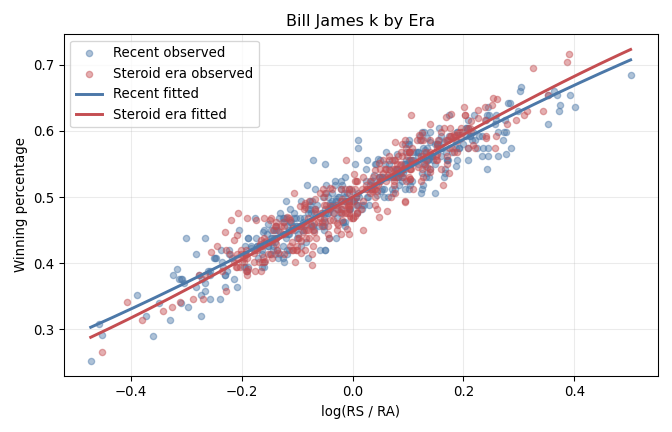

`log_run_ratio`의 계수는 최근 시대의 `k`를 추정하고,
`steroid_log_ratio`의 계수는 스테로이드 시대와 최근 시대의 차이인 `g`를
추정한다. 따라서 `steroid_log_ratio` 계수의 Wald 검정 또는 공통 `k`
모형과 시대별 `k` 모형의 likelihood-ratio 검정이 곧 $H_0: g = 0$에 대한
검정이다.

적합 결과에서 `g`의 추정값이 양수이고 p-value가 5% 수준에서 작게
나타나면, 스테로이드 시대의 `k`가 최근 시대보다 더 컸다는 증거가 있다.
이는 같은 득실점 비율 차이가 있을 때 스테로이드 시대에는 승률 차이로 더
크게 연결되었다는 의미이다. 다만 `k`는 PED 사용 자체를 직접 측정한 값이
아니라 득점과 실점이 승률로 변환되는 경험적 관계의 기울기이므로, 이
결과만으로 PED의 직접 인과효과를 결론낼 수는 없다.

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

``` yaml
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888
```

### 답안

저장소 최상위 디렉토리에 `Dockerfile`을 만들었다. 기본 구조는 제시된
예시와 같고, `hw03.qmd` 실행에 필요한 추가 패키지를 함께 설치하도록
설정하였다. R에서는 `NHANES`, `Lahman`을 추가했고, Python에서는 `scipy`,
`statsmodels`, `pylahman`을 추가하였다. 생성된 컨테이너는
`_site/hw03.ipynb`를 Binder 사용자 홈 디렉토리의 `hw03.ipynb`로
복사하도록 설정되어 있다.

In [ ]:
ls Dockerfile

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

``` yaml
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest
```

### 답안

`.github/workflows/publish.yml`을 수정하여 Quarto 렌더링과 GitHub Pages
배포 이후 Docker 이미지를 GitHub Container Registry(GHCR)에 푸시하도록
설정하였다. GHCR에 패키지를 올려야 하므로 job 권한에 `packages: write`를
추가하였다. 저장소 루트의 `hw03.qmd`를 `_quarto.yml`이 렌더링하도록
설정했기 때문에, Actions에서 `quarto render`를 실행하면
`_site/hw03.html`과 `_site/hw03.ipynb`가 생성된다. 이후 3-1에서 작성한
`Dockerfile`이 `_site/hw03.ipynb`를 컨테이너 안으로 복사한다.

추가한 Docker 관련 단계는 다음과 같다.

``` yaml
      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository }}:latest
```

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

``` markdown
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb
```

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

저장소 첫 페이지로 사용될 `README.md`를 숙제 3용으로 수정하였다. 분석
리포트는 GitHub Pages에 배포된 `hw03.html`을 가리키고, 노트북은 Binder가
`gh-pages` 브랜치의 `hw03.ipynb`를 열도록 링크하였다.

``` markdown
# 숙제 3

이름: 서재희
학번: 2025-23104

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html)
* [주피터 노트북 (Binder)](https://mybinder.org/v2/gh/snu-stat/hw3-2-seojaehee02/gh-pages?filepath=hw03.ipynb)
```

작업을 원격 저장소 `https://github.com/snu-stat/hw3-2-seojaehee02`에
push한 뒤에는 GitHub의 Actions 탭에서
`Quarto Publish (R & Custom Packages)` 워크플로우와
`pages build and deployment` 워크플로우가 모두 성공했는지 확인한다. 그
다음 Settings \> Pages에서 배포 브랜치를 `gh-pages`, 폴더를 `/ (root)`로
설정하면 웹페이지는 다음 주소에서 확인할 수 있다.

``` markdown
https://snu-stat.github.io/hw3-2-seojaehee02/
```